# Question 1

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    zero_one_loss
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, zero_one_loss, precision_score, recall_score

In [23]:
#load dataset

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets
y = y.squeeze()

# metadata
print(spambase.metadata)

# variable information
print(spambase.variables)


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [24]:
#train the decision tree

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 50,
    stratify = y
)

dt_entropy = DecisionTreeClassifier(
    criterion = "entropy",
    max_depth = None,
    random_state = 50
)

dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=50)

In [25]:
#predictions
y_train_pred = dt_entropy.predict(X_train)
y_test_pred = dt_entropy.predict(X_test)
y_train_prob = dt_entropy.predict_proba(X_train)[:, 1]
y_test_prob = dt_entropy.predict_proba(X_test)[:, 1]

In [26]:
#metrics
train_error = zero_one_loss(y_train, y_train_pred)
test_error = zero_one_loss(y_test, y_test_pred)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

#print results
print("Problem 1 Part 1: Decision Tree with Information Gain")
print(f"Training Error:   {train_error:.4f}")
print(f"Testing Error:    {test_error:.4f}")
print(f"Training Accuracy:{train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training F1:      {train_f1:.4f}")
print(f"Testing F1:       {test_f1:.4f}")
print(f"Training AUC:     {train_auc:.4f}")
print(f"Testing AUC:      {test_auc:.4f}")

Problem 1 Part 1: Decision Tree with Information Gain
Training Error:   0.0005
Testing Error:    0.0738
Training Accuracy:0.9995
Testing Accuracy: 0.9262
Training F1:      0.9993
Testing F1:       0.9040
Training AUC:     1.0000
Testing AUC:      0.9184


**Observations:**
The decision tree using information gain performed almost perfectly on the training set with a training error of 0.0005, training accuracy of 0.9995, training F1 of 0.9993, and training AUC of 1.000. This shows that the unpruned tree fit the training data extremely closely. On the testing set, the model still performed well with a testing error of 0.0738, testing accuracy of 0.9262, testing F1 of 0.9040, and testing AUC of 0.9184. The testing metrics are still strong and the model is learning patterns for distinguishing spam vs ham. However, the gap betwwen the training and testing metrics suggests that the tree could be overfitting the training data.

In [27]:
#train decision tree with Gini index

dt_gini = DecisionTreeClassifier(
    criterion = "gini",
    max_depth = None,
    random_state = 50
)

dt_gini.fit(X_train, y_train)

y_train_pred = dt_gini.predict(X_train)
y_test_pred = dt_gini.predict(X_test)

y_train_prob = dt_gini.predict_proba(X_train)[:, 1]
y_test_prob = dt_gini.predict_proba(X_test)[:, 1]

train_error = zero_one_loss(y_train, y_train_pred)
test_error = zero_one_loss(y_test, y_test_pred)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

In [28]:
print("Problem 1 Part 2: Decision Tree with Gini Index")
print(f"Training Error:   {train_error:.4f}")
print(f"Testing Error:    {test_error:.4f}")
print(f"Training Accuracy:{train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training F1:      {train_f1:.4f}")
print(f"Testing F1:       {test_f1:.4f}")
print(f"Training AUC:     {train_auc:.4f}")
print(f"Testing AUC:      {test_auc:.4f}")

Problem 1 Part 2: Decision Tree with Gini Index
Training Error:   0.0005
Testing Error:    0.0988
Training Accuracy:0.9995
Testing Accuracy: 0.9012
Training F1:      0.9993
Testing F1:       0.8752
Training AUC:     1.0000
Testing AUC:      0.8985


**Comparison to the informaton gain tree:** The Gini index tree had almost identical training performance to the information gain tree. Both models had a training error of 0.0005, training accuracy of 0.9995, training F1 of 0.9993, and training AUC of 1.0000. This means both trees fit the training data almost perfectly. However, the information gain tree performed better on the testing set. Its testing error was lower at 0.0738 compared to 0.0988 for the Gini tree. Its testing accuracy was higher at 0.9262 compared to 0.9012, its testing F1 was higher at 0.9040 compared to 0.8752, and its testing AUC was also higher at 0.9184 compared to 0.8985. This suggests that although both splitting criteria allow the tree to fit the training set extremely well, the information gain tree generalized better to unseen data.

Depth | Train Error | Test Error
    1 | 0.2052      | 0.2106
    2 | 0.1353      | 0.1357
    3 | 0.1111      | 0.1270
    4 | 0.0880      | 0.1064
    5 | 0.0802      | 0.1010
    6 | 0.0731      | 0.0945
    7 | 0.0671      | 0.0879
    8 | 0.0579      | 0.0825
    9 | 0.0470      | 0.0695
   10 | 0.0408      | 0.0673
   11 | 0.0310      | 0.0695
   12 | 0.0258      | 0.0662
   13 | 0.0201      | 0.0651
   14 | 0.0177      | 0.0630
   15 | 0.0141      | 0.0630
   16 | 0.0109      | 0.0673
   17 | 0.0092      | 0.0651
   18 | 0.0065      | 0.0651
   19 | 0.0052      | 0.0651
   20 | 0.0049      | 0.0695
   21 | 0.0041      | 0.0630
   22 | 0.0027      | 0.0738
   23 | 0.0024      | 0.0684
   24 | 0.0016      | 0.0608
   25 | 0.0014      | 0.0706
   26 | 0.0011      | 0.0717
   27 | 0.0008      | 0.0673
   28 | 0.0005      | 0.0738
   29 | 0.0005      | 0.0738
   30 | 0.0005      | 0.0738

Optimal depth based on minimum test error: 24
Minimum testing error: 0.0608


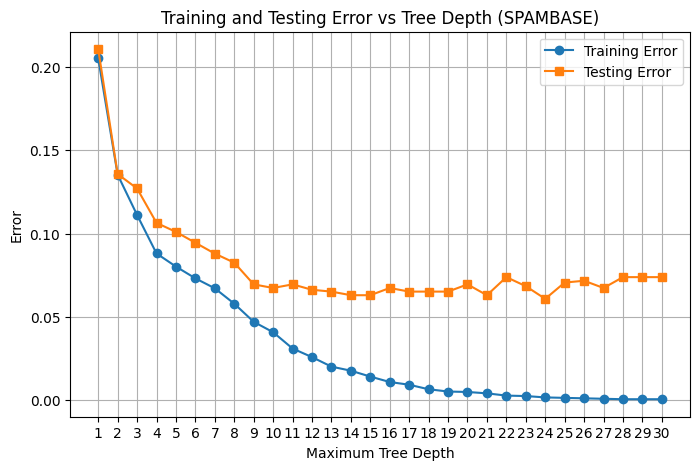

In [29]:
#part 3, prune by setting upper bound on max_depth

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 50,
    stratify = y
)

depth_values = range(1, 31)
train_errors = []
test_errors = []

for depth in depth_values:
    clf = DecisionTreeClassifier(
        criterion = "entropy",
        max_depth = depth,
        random_state = 50
    )
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_error = zero_one_loss(y_train, y_train_pred)
    test_error = zero_one_loss(y_test, y_test_pred)
    train_errors.append(train_error)
    test_errors.append(test_error)

#find best depth
best_index = np.argmin(test_errors)
best_depth = list(depth_values)[best_index]
best_test_error = test_errors[best_index]

print("Depth | Train Error | Test Error")
for d, tr, te in zip(depth_values, train_errors, test_errors):
    print(f"{d:5d} | {tr:.4f}      | {te:.4f}")

print(f"\nOptimal depth based on minimum test error: {best_depth}")
print(f"Minimum testing error: {best_test_error:.4f}")

#plot error vs. depth
plt.figure(figsize=(8, 5))
plt.plot(depth_values, train_errors, marker = 'o', label = 'Training Error')
plt.plot(depth_values, test_errors, marker = 's', label = 'Testing Error')
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Error")
plt.title("Training and Testing Error vs Tree Depth (SPAMBASE)")
plt.xticks(depth_values)
plt.grid(True)
plt.legend()
plt.show()

**Observations**: The graph shows that at very small depths, both the training error and testing error are high. For example, at depth 1 the training error is 0.2052 and the testing error is 0.2106. As the depth increases, the training error drops steadily, which makes sense because a deeper tree can fit the training set more closely. After about depth 14 to 15, the testing error stops improving consistently and starts to fluctuate, while the training error keeps getting closer to 0. This indicates overfitting. **I would recommend a maximum tree depth of 24, since it gives the lowest testing error of 0.0608.**

# Problem 2

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

T_values = [10, 50, 100, 500]
results = []

for T in T_values:
    rf = RandomForestClassifier(
        n_estimators=T,
        random_state=50,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    #predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    #probabilities for AUC
    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]
    #metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)

    results.append({
        "T": T,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Train AUC": train_auc,
        "Test AUC": test_auc
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index = False))

  T  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC
 10        0.995109       0.947883  0.993772 0.932394   0.999927  0.978579
 50        0.999457       0.952226  0.999310 0.937853   0.999998  0.985194
100        0.999457       0.953312  0.999310 0.939351   0.999999  0.985436
500        0.999457       0.952226  0.999310 0.938202   0.999999  0.986273


**Observations:** As the number of trees increases, the random forest performs very well on both the training and testing sets, and the testing metrics improve slightly before leveling off. On the training set, the model is already extremely strong with T=10, with training accuracy 0.9951, training F1 0.9938, and training AUC 0.9999. As
T increases to 50, 100, and 500, the training metrics become almost perfect and then stay essentially unchanged. This shows that the random forest fits the training data very well even with a relatively small number of trees. On the testing set, the performance improves from T=10 to T=100. Test accuracy increases from 0.9479 to 0.9533, test F1 increases from 0.9324 to 0.9394, and test AUC increases from 0.9786 to 0.9854. This suggests that adding more trees helps the model generalize better at first by making the ensemble more stable.

**Comparison to problem 1:** The random forest outperformed the single decision tree from problem 1. The best decision tree which used information gain achieved a test accuracy of 0.9262, test F1 of 0.9040, and test AUC of 0.9184. In comparison, the random forest with 100 trees achieved a test accuracy of 0.9533, test F1 of 0.9394, and test AUC of 0.9854. Therefore, the random forest produced better predictive performance on all of the testing metrics. This suggests that the ensemble method generalized better than a single decision tree and was less sensitive to overfitting.

                   Feature  Importance
               char_freq_!    0.125099
               char_freq_$    0.098836
          word_freq_remove    0.078242
            word_freq_free    0.065771
            word_freq_your    0.060490
capital_run_length_average    0.058614
capital_run_length_longest    0.057958
              word_freq_hp    0.052485
  capital_run_length_total    0.041593
           word_freq_money    0.030170
             word_freq_you    0.026748
             word_freq_our    0.023820
          word_freq_george    0.020151
             word_freq_hpl    0.019731
             word_freq_edu    0.019433
             word_freq_000    0.019011
        word_freq_business    0.014298
            word_freq_1999    0.013392
        word_freq_internet    0.013391
               char_freq_(    0.012983
             word_freq_all    0.011876
         word_freq_receive    0.010423
            word_freq_will    0.010412
              word_freq_re    0.010145
           word_freq_emai

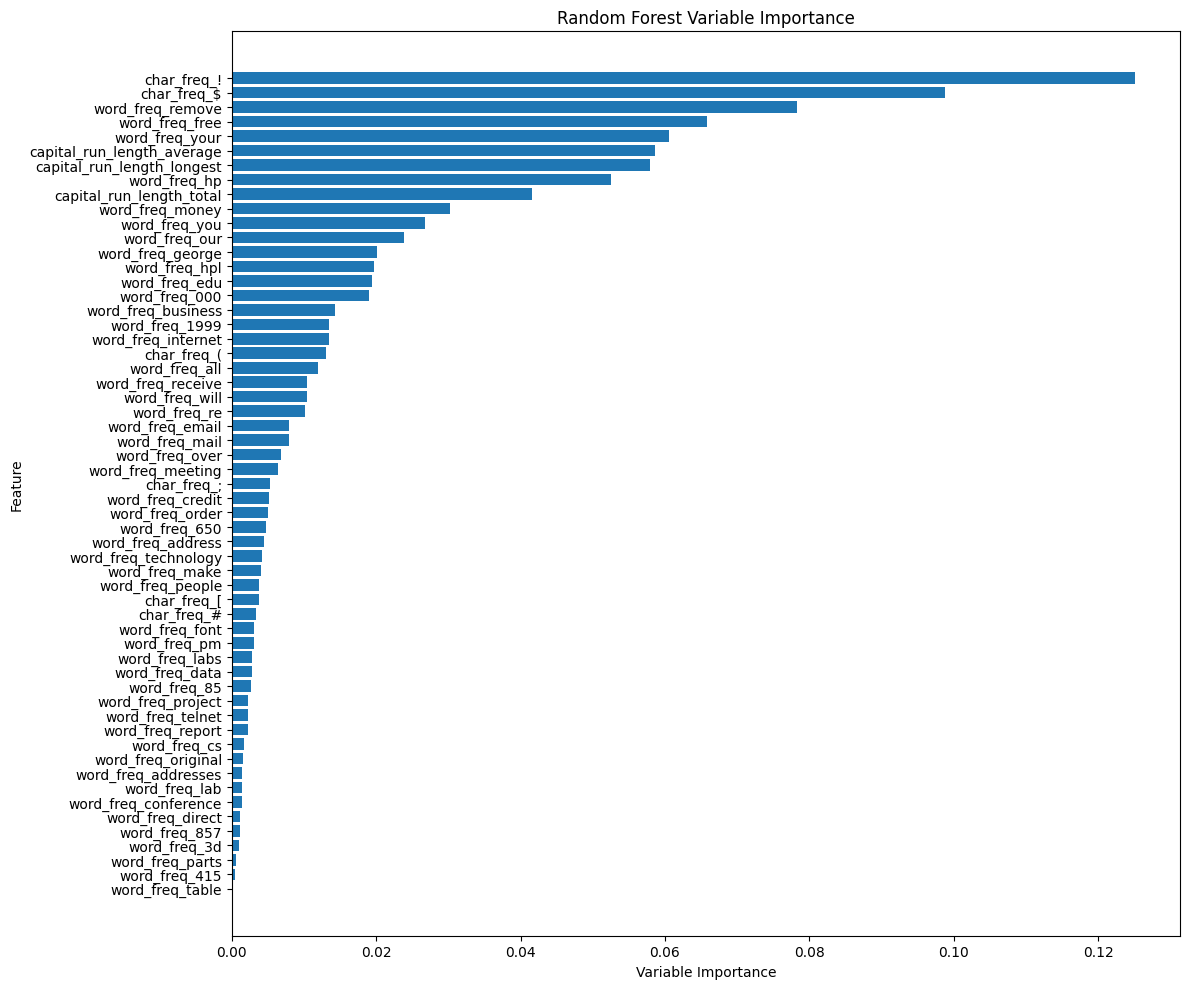

In [31]:
best_rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 50,
    n_jobs = -1
)
best_rf.fit(X_train, y_train)

# variable importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending = False)

# print all feature importances
print(importance_df.to_string(index=False))

# plot all feature importances
plt.figure(figsize=(12, 10))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Variable Importance")
plt.ylabel("Feature")
plt.title("Random Forest Variable Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Problem 3

In [32]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

T_values = [10, 50, 100, 500]
ada_results = []

base_tree = DecisionTreeClassifier(max_depth = 1, random_state = 50)

for T in T_values:
    ada = AdaBoostClassifier(
        estimator = base_tree,
        n_estimators = T,
        random_state = 50
    )

    ada.fit(X_train, y_train)

    #predictions
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    #probabilities for AUC
    y_train_prob = ada.predict_proba(X_train)[:, 1]
    y_test_prob = ada.predict_proba(X_test)[:, 1]
    #metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)

    ada_results.append({
        "T": T,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Train AUC": train_auc,
        "Test AUC": test_auc
    })

ada_results_df = pd.DataFrame(ada_results)
print(ada_results_df.to_string(index = False))

  T  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC
 10        0.902446       0.903366  0.874956 0.874471   0.957365  0.954506
 50        0.933967       0.928339  0.914286 0.906516   0.980853  0.977157
100        0.941848       0.930510  0.925018 0.910364   0.985166  0.980872
500        0.958152       0.942454  0.946491 0.926897   0.991162  0.983797


Comparison to Random Forest: Random Forest performs better on both the training and testing sets for all values of T. For example, at T=100, Random Forest achieved a test accuracy of 0.9533, test F1 of 0.9394, and test AUC of 0.9854, while AdaBoost achieved a test accuracy of 0.9305, test F1 of 0.9104, and test AUC of 0.9809. AdaBoost shows steady improvement as the number of base learners increases, whereas Random Forest reaches very strong performance earlier and then levels off. Overall, Random Forest appears to generalize better than AdaBoost.

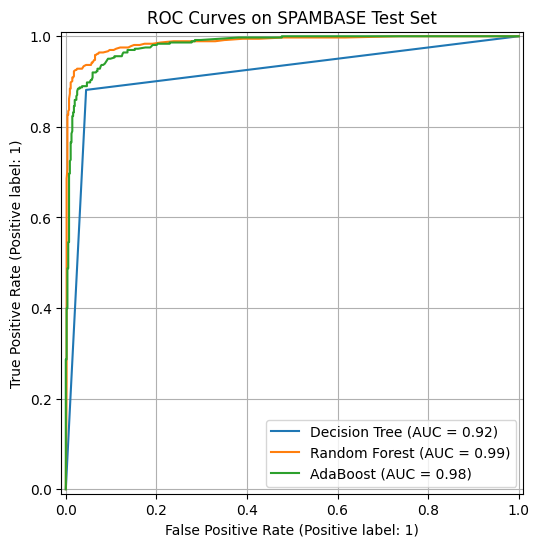

In [33]:
from sklearn.metrics import RocCurveDisplay

#fit the three models
dt_model = DecisionTreeClassifier(
    criterion = "entropy",
    random_state = 50
)

rf_100_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 50,
    n_jobs = -1
)

ada_100_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth = 1, random_state = 50),
    n_estimators = 100,
    random_state = 50
)

dt_model.fit(X_train, y_train)
rf_100_model.fit(X_train, y_train)
ada_100_model.fit(X_train, y_train)

#plot ROC curves on the test set
plt.figure(figsize = (8, 6))

RocCurveDisplay.from_estimator(dt_model, X_test, y_test, name = "Decision Tree",
                               ax = plt.gca())
RocCurveDisplay.from_estimator(rf_100_model, X_test, y_test,
                               name = "Random Forest", ax = plt.gca())
RocCurveDisplay.from_estimator(ada_100_model, X_test, y_test,
                               name= "AdaBoost", ax = plt.gca())

plt.title("ROC Curves on SPAMBASE Test Set")
plt.grid(True)
plt.show()

# Problem 4

In [34]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
mushroom = fetch_ucirepo(id=73)

# data (as pandas dataframes)
X = mushroom.data.features
y = mushroom.data.targets

# metadata
print(mushroom.metadata)

# variable information
print(mushroom.variables)


{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

In [35]:
X_mush = mushroom.data.features.copy()
y_mush = mushroom.data.targets.squeeze().copy()

X_mush = X_mush.fillna("missing").astype(str)
y_mush = y_mush.astype(str)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mush,
    y_mush,
    test_size=0.25,
    random_state=50,
    stratify=y_mush
)

#naive bayes classifier
class MyNaiveBayes:
    def __init__(self):
        self.class_priors = {}
        self.cond_probs = {}
        self.feature_values = {}
        self.classes = None
        self.class_counts = {}

    def fit(self, X, y):
        X = X.copy()
        y = pd.Series(y).copy()

        self.classes = list(sorted(y.unique().tolist()))
        for feature in X.columns:
            self.feature_values[feature] = list(sorted(X[feature].astype(str).unique().tolist()))

        n = len(y)
        for c in self.classes:
            class_count = (y == c).sum()
            self.class_counts[c] = class_count
            self.class_priors[c] = class_count / n

        # conditional probabilities with Laplace smoothing
        self.cond_probs = {}
        for c in self.classes:
            self.cond_probs[c] = {}
            X_c = X[y == c]
            for feature in X.columns:
                self.cond_probs[c][feature] = {}
                possible_vals = self.feature_values[feature]
                k = len(possible_vals)
                denom = len(X_c) + k
                value_counts = X_c[feature].value_counts()
                for val in possible_vals:
                    count = value_counts.get(val, 0)
                    prob = (count + 1) / denom
                    self.cond_probs[c][feature][val] = prob

        return self

my_nb = MyNaiveBayes()
my_nb.fit(X_train_m, y_train_m)

#show conditional probabilities
example_features = X_train_m.columns[:3]
for c in my_nb.classes:
    print(f"\nConditional probabilities for class {c}:")
    for feature in example_features:
        print(f"\nFeature: {feature}")
        for val, prob in my_nb.cond_probs[c][feature].items():
            print(f"P({feature} = {val} | Y = {c}) = {prob:.6f}")


Conditional probabilities for class e:

Feature: cap-shape
P(cap-shape = b | Y = e) = 0.100886
P(cap-shape = c | Y = e) = 0.000316
P(cap-shape = f | Y = e) = 0.376660
P(cap-shape = k | Y = e) = 0.055661
P(cap-shape = s | Y = e) = 0.006958
P(cap-shape = x | Y = e) = 0.459519

Feature: cap-surface
P(cap-surface = f | Y = e) = 0.373101
P(cap-surface = g | Y = e) = 0.000316
P(cap-surface = s | Y = e) = 0.268354
P(cap-surface = y | Y = e) = 0.358228

Feature: cap-color
P(cap-color = b | Y = e) = 0.011055
P(cap-color = c | Y = e) = 0.007896
P(cap-color = e | Y = e) = 0.150347
P(cap-color = g | Y = e) = 0.249526
P(cap-color = n | Y = e) = 0.296589
P(cap-color = p | Y = e) = 0.013582
P(cap-color = r | Y = e) = 0.004106
P(cap-color = u | Y = e) = 0.004422
P(cap-color = w | Y = e) = 0.168035
P(cap-color = y | Y = e) = 0.094441

Conditional probabilities for class p:

Feature: cap-shape
P(cap-shape = b | Y = p) = 0.012912
P(cap-shape = c | Y = p) = 0.001359
P(cap-shape = f | Y = p) = 0.395175
P(

In [36]:
def predict_proba_custom(model, X):
    X = X.copy().fillna("missing").astype(str)
    prob_rows = []

    for _, row in X.iterrows():
        log_scores = {}

        for c in model.classes:
            #start with log prior
            log_prob = np.log(model.class_priors[c])
            for feature in X.columns:
                val = row[feature]

                #if value was seen in training, use stored conditional probability
                if val in model.cond_probs[c][feature]:
                    cond_prob = model.cond_probs[c][feature][val]
                else:
                    #fallback for unseen value
                    k = len(model.feature_values[feature])
                    cond_prob = 1 / (model.class_counts[c] + k)

                log_prob += np.log(cond_prob)
            log_scores[c] = log_prob

        #convert log scores to normalized probabilities
        max_log = max(log_scores.values())
        exp_scores = {c: np.exp(log_scores[c] - max_log) for c in model.classes}
        total = sum(exp_scores.values())
        probs = {c: exp_scores[c] / total for c in model.classes}
        prob_rows.append(probs)

    return pd.DataFrame(prob_rows, index=X.index)

#probabilities for each test example
test_prob_df = predict_proba_custom(my_nb, X_test_m)

print(test_prob_df.head(10))

                 e             p
8089  2.374261e-13  1.000000e+00
1370  9.999977e-01  2.299400e-06
471   1.000000e+00  2.451617e-11
7838  9.999499e-01  5.007849e-05
3756  9.999787e-01  2.134218e-05
5418  1.082963e-03  9.989170e-01
5469  4.272885e-12  1.000000e+00
3786  9.999973e-01  2.729666e-06
5455  3.675011e-13  1.000000e+00
4642  1.362308e-12  1.000000e+00


In [37]:
y_pred_m = test_prob_df[my_nb.classes].idxmax(axis=1)

#choose Poisonous as the positive class
if "p" in y_test_m.unique():
    pos_class = "p"
elif "poisonous" in [str(x).lower() for x in y_test_m.unique()]:
    pos_class = [x for x in y_test_m.unique() if str(x).lower() == "poisonous"][0]
else:
    pos_class = sorted(y_test_m.unique())[-1]   # fallback

accuracy = accuracy_score(y_test_m, y_pred_m)
precision = precision_score(y_test_m, y_pred_m, pos_label=pos_class)
recall = recall_score(y_test_m, y_pred_m, pos_label=pos_class)
f1 = f1_score(y_test_m, y_pred_m, pos_label=pos_class)

print("Positive class used for precision/recall/F1:", pos_class)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Positive class used for precision/recall/F1: p
Accuracy:  0.9581
Precision: 0.9978
Recall:    0.9152
F1 Score:  0.9547


In [38]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

encoder = OrdinalEncoder()
X_train_enc = encoder.fit_transform(X_train_m)
X_test_enc = encoder.transform(X_test_m)

#package Naive Bayes model
pkg_nb = CategoricalNB(alpha=1.0)
pkg_nb.fit(X_train_enc, y_train_m)
y_pred_pkg = pkg_nb.predict(X_test_enc)

if "p" in y_test_m.unique():
    pos_class = "p"
elif "poisonous" in [str(x).lower() for x in y_test_m.unique()]:
    pos_class = [x for x in y_test_m.unique() if str(x).lower() == "poisonous"][0]
else:
    pos_class = sorted(y_test_m.unique())[-1]

#metrics for package model
pkg_accuracy = accuracy_score(y_test_m, y_pred_pkg)
pkg_precision = precision_score(y_test_m, y_pred_pkg, pos_label=pos_class)
pkg_recall = recall_score(y_test_m, y_pred_pkg, pos_label=pos_class)
pkg_f1 = f1_score(y_test_m, y_pred_pkg, pos_label=pos_class)

print("Package Naive Bayes metrics")
print(f"Accuracy:  {pkg_accuracy:.4f}")
print(f"Precision: {pkg_precision:.4f}")
print(f"Recall:    {pkg_recall:.4f}")
print(f"F1 Score:  {pkg_f1:.4f}")

Package Naive Bayes metrics
Accuracy:  0.9581
Precision: 0.9978
Recall:    0.9152
F1 Score:  0.9547


**Comparison:** The two models produced exactly the same results on the testing set: accuracy = 0.9581, precision = 0.9978, recall = 0.9152, and F1 score = 0.9547. This confirms that my implementation of Naive Bayes, including the prior probabilities, conditional probabilities, Laplace smoothing, and classification rule, was correct.